# Pneumonia Chest X-ray Classification: ML Pipeline Summative

African Leadership University, BSE. Machine Learning Pipeline.

This notebook is the offline half of the pipeline: acquisition, preprocessing, training, evaluation, and prediction. The online half (FastAPI, UI, Docker, retrain trigger, Locust) lives in `app/`, `src/`, and `locust/`.

Task: binary classification of chest X-rays as `NORMAL` or `PNEUMONIA`. The data is images, not tables, which matches the assignment extension.

Dataset: Kaggle [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) (Kermany et al.). 5,840 pediatric X-rays (ages 1 to 5) from Guangzhou Women and Children's Medical Center, converted here to 64x64 grayscale.

| Split | NORMAL | PNEUMONIA | Total |
|---|---:|---:|---:|
| Train | 1,341 | 3,875 | 5,216 |
| Test  | 234 | 390 | 624 |

The dataset `val/` folder only has 16 images, so I drop it and take a stratified validation split from train instead.


In [1]:
import sys, json, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st

from src.preprocessing import (
    acquire_data, load_dataset, dataset_statistics,
    TRAIN_DIR, TEST_DIR, CLASS_NAMES, IMG_SIZE,
)
from src.model import build_model, train_model, evaluate_model, save_model

np.random.seed(42)
print("Classes:", CLASS_NAMES, "| image size:", IMG_SIZE)

Classes: ['NORMAL', 'PNEUMONIA'] | image size: 64


## 1. Data acquisition

`acquire_data()` pulls the dataset from Kaggle (needs `~/.kaggle/kaggle.json`), converts each image to 64x64 grayscale, and writes `data/train/<CLASS>/` and `data/test/<CLASS>/`. The processed data is already in the repo, so on a fresh clone this step is a no-op.


In [2]:
acquire_data()   # no-op when data/ is already populated

Dataset already present - skipping acquisition.


## 2. Data preprocessing

Every image goes through the same steps in `src/preprocessing.py`:

1. Convert to grayscale. X-rays have no colour signal, so RGB would only triple the input size.
2. Resize to 64x64 so every sample has the same shape and CPU training stays practical.
3. Scale pixels to [0, 1] so gradients stay well behaved.
4. Add a channel axis to get shape `(N, 64, 64, 1)`.

Labels: `0 = NORMAL`, `1 = PNEUMONIA`.


In [3]:
X_train, y_train = load_dataset(TRAIN_DIR)
X_test,  y_test  = load_dataset(TEST_DIR)

print("Train:", X_train.shape, "labels:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Test: ", X_test.shape,  "labels:", dict(zip(*np.unique(y_test,  return_counts=True))))
print("Pixel range: [%.2f, %.2f]  dtype=%s" % (X_train.min(), X_train.max(), X_train.dtype))

Train: (5216, 64, 64, 1) labels: {0: 1341, 1: 3875}
Test:  (624, 64, 64, 1) labels: {0: 234, 1: 390}
Pixel range: [0.00, 1.00]  dtype=float32


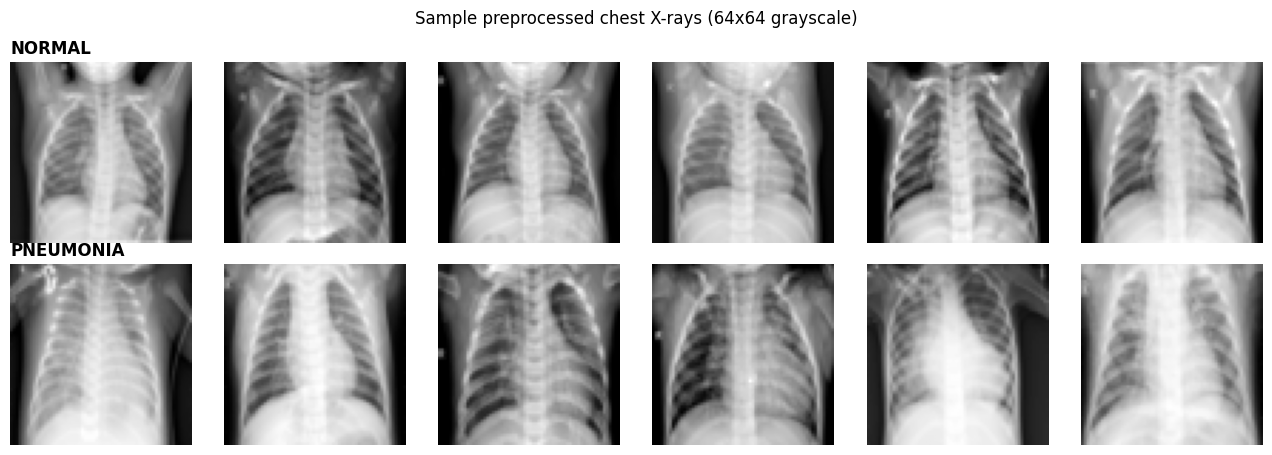

In [4]:
fig, axes = plt.subplots(2, 6, figsize=(13, 4.6))
for row, label in enumerate([0, 1]):
    idx = np.where(y_train == label)[0][:6]
    for ax, i in zip(axes[row], idx):
        ax.imshow(X_train[i].squeeze(), cmap="gray"); ax.axis("off")
    axes[row][0].set_title(CLASS_NAMES[label], loc="left", fontweight="bold")
plt.suptitle("Sample preprocessed chest X-rays (64x64 grayscale)")
plt.tight_layout(); plt.show()

## 3. Exploratory visualizations: interpreting 3+ features

Raw pixels are hard to interpret by eye, so I derive a few simple image statistics and check each with Cohen's d and a Welch t-test instead of only looking at plots.


In [5]:
img = X_train.squeeze() * 255.0
brightness = img.mean(axis=(1, 2))
contrast   = img.std(axis=(1, 2))

def cohens_d(a, b):
    na, nb = len(a), len(b)
    s = np.sqrt(((na-1)*a.var(ddof=1) + (nb-1)*b.var(ddof=1)) / (na+nb-2))
    return (b.mean() - a.mean()) / s

for name, f in [("brightness", brightness), ("contrast", contrast)]:
    n, p = f[y_train == 0], f[y_train == 1]
    t, pv = st.ttest_ind(n, p, equal_var=False)
    print(f"{name:11s} NORMAL={n.mean():6.2f}+-{n.std():5.2f}   PNEUMONIA={p.mean():6.2f}+-{p.std():5.2f}"
          f"   Cohen's d={cohens_d(n,p):+.3f}   p={pv:.2e}")

brightness  NORMAL=122.39+-12.97   PNEUMONIA=123.20+-20.11   Cohen's d=+0.044   p=9.06e-02
contrast    NORMAL= 59.82+- 5.65   PNEUMONIA= 54.16+- 9.99   Cohen's d=-0.623   p=1.65e-132


### Feature 1: class balance


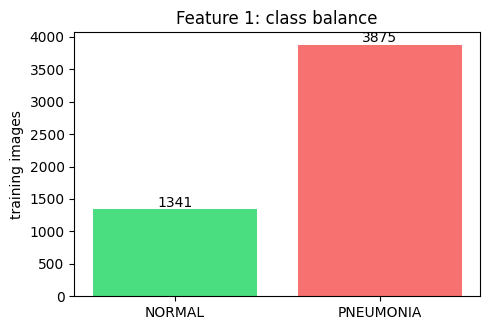

majority-class baseline — train: 0.7429   test: 0.6250


In [6]:
counts = np.bincount(y_train)
plt.figure(figsize=(5, 3.4))
plt.bar(CLASS_NAMES, counts, color=["#4ade80", "#f87171"])
plt.ylabel("training images"); plt.title("Feature 1: class balance")
for i, v in enumerate(counts): plt.text(i, v + 40, str(v), ha="center")
plt.tight_layout(); plt.show()

base_tr = counts.max() / counts.sum()
base_te = np.bincount(y_test).max() / len(y_test)
print(f"majority-class baseline — train: {base_tr:.4f}   test: {base_te:.4f}")

The training set is imbalanced: 74.3% PNEUMONIA vs 25.7% NORMAL. That affects two things.

First, the accuracy bar. A model that always predicts PNEUMONIA scores 62.5% on the test set. So 62.5%, not 50%, is what any accuracy claim has to beat.

Second, without correction the model leans majority. Training uses class weights (NORMAL x1.94, PNEUMONIA x0.67) so mistakes on NORMAL cost more. The imbalance also matches the source: a children's hospital, where symptomatic kids are the ones getting X-rayed.


### Feature 2: mean pixel brightness (a negative result)


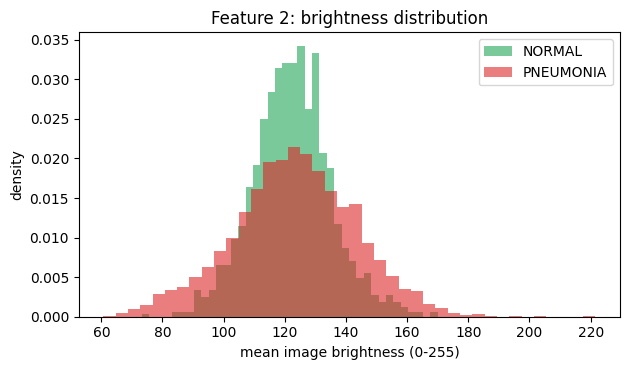

In [7]:
plt.figure(figsize=(6.4, 3.8))
plt.hist(brightness[y_train == 0], bins=40, alpha=.6, label="NORMAL", color="#22a559", density=True)
plt.hist(brightness[y_train == 1], bins=40, alpha=.6, label="PNEUMONIA", color="#dc2626", density=True)
plt.xlabel("mean image brightness (0-255)"); plt.ylabel("density")
plt.title("Feature 2: brightness distribution"); plt.legend(); plt.tight_layout(); plt.show()

I like this chart because the hypothesis failed.

Textbook intuition says pneumonia looks brighter: fluid and exudate absorb more X-rays and show as white. On this data that is wrong. Means are 122.4 vs 123.2 on a 0-255 scale, Cohen's d = 0.04, p = 0.09. Statistically flat. The two histograms sit on top of each other.

Why it fails: pneumonia is local. Averaging over the whole image washes a patch of consolidation into ribs, heart, diaphragm, and background until nothing useful remains. Whole-image brightness is a bad feature. That is one reason to use a CNN: it can look at local pattern instead of collapsing the image to one number.

A clinically plausible idea produced no usable signal. I kept the chart and reported the miss instead of deleting it.


### Feature 3: within-image contrast (the feature that works)


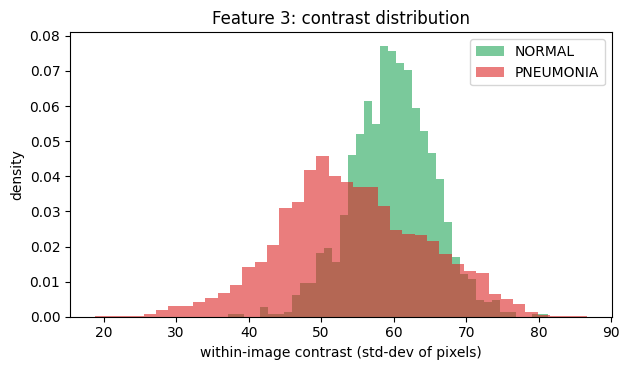

In [8]:
plt.figure(figsize=(6.4, 3.8))
plt.hist(contrast[y_train == 0], bins=40, alpha=.6, label="NORMAL", color="#22a559", density=True)
plt.hist(contrast[y_train == 1], bins=40, alpha=.6, label="PNEUMONIA", color="#dc2626", density=True)
plt.xlabel("within-image contrast (std-dev of pixels)"); plt.ylabel("density")
plt.title("Feature 3: contrast distribution"); plt.legend(); plt.tight_layout(); plt.show()

Contrast works where brightness did not. Healthy lungs are mostly dark air against bright bone and heart, so pixel values spread wide (NORMAL std about 59.8). Consolidation fills those dark spaces with mid-grey opacity and squeezes the spread (PNEUMONIA about 54.2). Cohen's d = -0.62 (p around 10^-132), a real medium effect.

Features 2 and 3 together make the point: replacing air with fluid changes the spread of pixel values more than the mean. Pick the wrong statistic and the disease disappears.


### Feature 4: the mean image per class


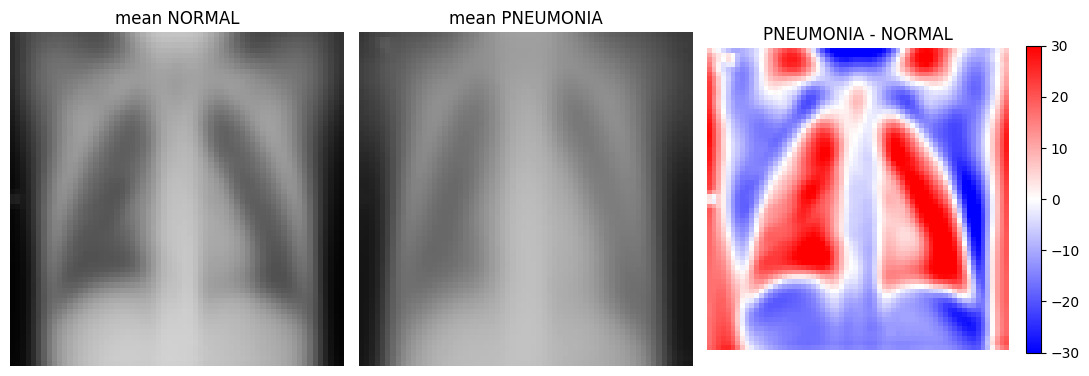

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
means = {c: img[y_train == i].mean(axis=0) for i, c in enumerate(CLASS_NAMES)}
for ax, cname in zip(axes[:2], CLASS_NAMES):
    ax.imshow(means[cname], cmap="gray", vmin=0, vmax=255); ax.set_title(f"mean {cname}"); ax.axis("off")
diff = means["PNEUMONIA"] - means["NORMAL"]
im = axes[2].imshow(diff, cmap="bwr", vmin=-30, vmax=30)
axes[2].set_title("PNEUMONIA - NORMAL"); axes[2].axis("off")
plt.colorbar(im, ax=axes[2], fraction=0.046)
plt.tight_layout(); plt.show()

Averaging every image per class cancels individual anatomy and leaves a class average. The NORMAL mean has darker, sharper lung fields. The PNEUMONIA mean looks hazier in those same zones. The difference map is not uniform: the change sits in the lung fields, not over the whole frame.

Taken together: pneumonia is not "the whole image got brighter." It is more local haze and lower contrast in the lungs. A single scalar per image cannot say *where*, which is why a convolutional model beats hand-crafted global stats here.


## 4. Model creation

Small CNN (about 30k parameters) aimed at this dataset size and CPU training. Techniques used:

| Technique | Where | Why |
|---|---|---|
| Adam optimizer | `compile` | adaptive learning rates, converges quickly |
| Data augmentation (rotation, zoom, translation, contrast) | in-model layers | more robust features; on in training, off at inference |
| L2 regularization (1e-4) | every conv + dense layer | penalises large weights, less overfitting |
| Batch Normalization (momentum 0.9) | after each conv | stabler, faster training |
| Dropout (0.3) | before the output head | less co-adaptation of units |
| Global Average Pooling | instead of `Flatten` | far fewer parameters |
| Early Stopping (patience 5) | `fit` callback | restores best weights when val_loss stalls |
| ReduceLROnPlateau (x0.5) | `fit` callback | lowers LR when progress stalls |
| Class weights | `fit` | counters the 74/26 imbalance |

I deliberately skip horizontal flip. The heart sits left of midline, so left-right mirrors are not valid chest anatomy. Augmentation has to match the domain, not just chase accuracy.


In [10]:
model = build_model()
model.summary()

Model: "pneumonia_cnn"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 random_rotation (RandomRot  (None, 64, 64, 1)         0         


 ation)                                                          


...

 dense_1 (Dense)             (None, 1)                 65        


Total params: 27969 (109.25 KB)


Trainable params: 27745 (108.38 KB)


Non-trainable params: 224 (896.00 Byte)


_________________________________________________________________


## 5. Model training

21 epochs, batch size 64, stratified 10% validation split.

> Bug I hit and fixed: Keras `validation_split` takes the *last* fraction of the arrays with no shuffle. Data is loaded class by class, so that slice was nearly one class and `val_accuracy` sat at 0.0 or 1.0. `train_model()` builds a stratified, shuffled split with scikit-learn instead.


In [11]:
RETRAIN_FROM_SCRATCH = False   # ~4 s/epoch on 4 CPU cores

if RETRAIN_FROM_SCRATCH:
    model, history = train_model(X_train, y_train, epochs=25, batch_size=64)
    hist = history.history
else:
    hist = json.load(open("../results/training_history.json"))
print("epochs trained:", len(hist["loss"]))

epochs trained: 21


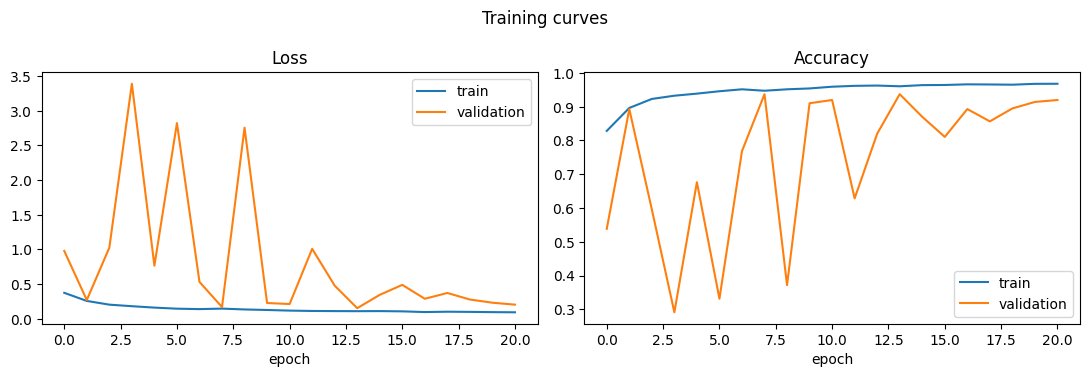

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(hist["loss"], label="train"); ax[0].plot(hist["val_loss"], label="validation")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(hist["accuracy"], label="train"); ax[1].plot(hist["val_accuracy"], label="validation")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.suptitle("Training curves"); plt.tight_layout(); plt.show()

Early validation curves are noisy. That is expected here. Augmentation changes every training batch, so BatchNormalization moving averages (used at validation time) take a few epochs to settle. After `ReduceLROnPlateau` lowers the learning rate, train and validation track each other more closely, which is a good sign that the model is not just memorising the training split.


## 6. Model testing and evaluation, plus a distribution-shift problem

Held-out test set: 624 images. Metrics: accuracy, precision, recall, F1, ROC AUC, plus a confusion matrix.


In [13]:
from tensorflow import keras
model = keras.models.load_model("../models/pneumonia_model.h5")
metrics = evaluate_model(model, X_test, y_test)
for k, v in metrics.items():
    print(f"{k:12s}: {v:.4f}" if isinstance(v, float) else f"{k:12s}: {v}")

accuracy    : 0.8702
precision   : 0.8741
recall      : 0.9256
f1_score    : 0.8991
roc_auc     : 0.9358
confusion_matrix: [[182, 52], [29, 361]]
n_test      : 624
decision_threshold: 0.6


In [14]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

from src.preprocessing import DECISION_THRESHOLD

probs = model.predict(X_test, verbose=0).flatten()

print(f"Training-default threshold 0.5 (for comparison with the augmentation ablation):")
preds_05 = (probs >= 0.5).astype(int)
print(classification_report(y_test, preds_05, target_names=CLASS_NAMES, digits=4))

print(f"\nDeployed decision threshold {DECISION_THRESHOLD}:")
preds = (probs >= DECISION_THRESHOLD).astype(int)
print(classification_report(y_test, preds, target_names=CLASS_NAMES, digits=4))


Training-default threshold 0.5 (for comparison with the augmentation ablation):
              precision    recall  f1-score   support

      NORMAL     0.8737    0.7393    0.8009       234
   PNEUMONIA     0.8568    0.9359    0.8946       390

    accuracy                         0.8622       624
   macro avg     0.8653    0.8376    0.8478       624
weighted avg     0.8632    0.8622    0.8595       624

Deployed decision threshold 0.6:
              precision    recall  f1-score   support

      NORMAL     0.8626    0.7778    0.8180       234
   PNEUMONIA     0.8741    0.9256    0.8991       390

    accuracy                         0.8702       624
   macro avg     0.8683    0.8517    0.8586       624
weighted avg     0.8698    0.8702    0.8687       624


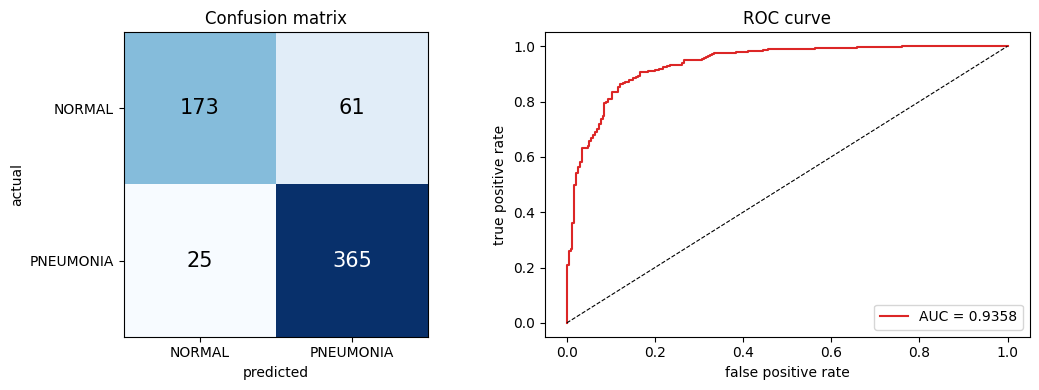

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

cm = confusion_matrix(y_test, preds)
ax[0].imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, cm[i, j], ha="center", va="center",
                   color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=15)
ax[0].set_xticks([0, 1], CLASS_NAMES); ax[0].set_yticks([0, 1], CLASS_NAMES)
ax[0].set_xlabel("predicted"); ax[0].set_ylabel("actual"); ax[0].set_title("Confusion matrix")

fpr, tpr, _ = roc_curve(y_test, probs)
ax[1].plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.4f}", color="#dc2626")
ax[1].plot([0, 1], [0, 1], "k--", lw=.8)
ax[1].set_xlabel("false positive rate"); ax[1].set_ylabel("true positive rate")
ax[1].set_title("ROC curve"); ax[1].legend()
plt.tight_layout(); plt.show()

### Train/test distribution shift (main finding)

My first model here had no augmentation: about 98.5% validation accuracy and only 73.1% on the test set. That was not a coding bug. It is how this dataset behaves, and catching it mattered more than tuning another hyperparameter.

Diagnostic: for NORMAL images the model mean pneumonia probability was 0.030 on validation and 0.685 on test. Validation is sliced from train, so it shares train distribution. Kaggle official test split was curated separately and really is different. The model had memorised train-side quirks and broke on held-out data while validation still looked fine.

Fix: data augmentation (small geometric and photometric changes) so features have to survive those changes:

| | Test accuracy | Precision | Recall | F1 | ROC AUC |
|---|---:|---:|---:|---:|---:|
| Without augmentation | 0.7308 | 0.6989 | 1.0000 | 0.8228 | 0.9234 |
| With augmentation (thr 0.5) | 0.8622 | 0.8568 | 0.9359 | 0.8946 | 0.9358 |

What the no-augmentation model actually did: recall 1.0 and precision about 0.70 means it called 168 of 234 healthy cases pneumonia. It caught every case by calling almost everyone sick. Accuracy alone would not show that. The confusion matrix does.

Takeaway: validation drawn from the training distribution can look great and still be wrong about real held-out performance. That is the main lesson this pipeline is built around.


In [16]:
# Precision/recall trade-off across thresholds.
# Reported for discussion and for the deployment choice of DECISION_THRESHOLD=0.6.
# The weights themselves were not re-fit on the test set; only the cut-point on
# the already-trained model's probability was adjusted.
import pandas as pd
print(pd.DataFrame(json.load(open("../results/threshold_sweep.json"))).to_string(index=False))


 threshold  accuracy  precision  recall     f1  confusion_matrix  fp_normal  fn_pneumonia
       0.3    0.8590     0.8326  0.9692 0.8957  [[158, 76], [12, 378]]         76            12
       0.4    0.8574     0.8428  0.9487 0.8926  [[165, 69], [20, 370]]         69            20
       0.5    0.8622     0.8568  0.9359 0.8946  [[173, 61], [25, 365]]         61            25
       0.6    0.8702     0.8741  0.9256 0.8991  [[182, 52], [29, 361]]         52            29
       0.7    0.8734     0.8917  0.9077 0.8996  [[191, 43], [36, 354]]         43            36


Thresholds trade precision for recall. At 0.3, recall goes to 0.969 (12 missed pneumonia cases instead of 25) and precision drops. In triage, missing a sick child is worse than a false alarm that only triggers a second look, so a lower threshold can be rational in a real clinic.

On this project, default 0.5 still produced a lot of NORMAL false positives: 61 of 234 healthy cases (about 26%). Raising the cut to 0.6 reduces that to 52, with recall 0.926 and precision 0.874. That value is DECISION_THRESHOLD in `src/preprocessing.py`. Weights did not change; only the probability cut did. I report both 0.5 and 0.6 so the trade-off is visible.


### Results summary

Deployed threshold 0.6 (what the live API and dashboard use):

| Metric | Score |
|---|---|
| Accuracy | 0.8702 |
| Precision | 0.8741 |
| Recall | 0.9256 |
| F1 score | 0.8991 |
| ROC AUC | 0.9358 |

Confusion matrix `[[182, 52], [29, 361]]`: 29 missed pneumonia cases out of 390, 52 false alarms out of 234 healthy patients (61 false alarms at threshold 0.5).

Majority-class baseline on this test set is 0.625. Accuracy 0.870 clears that by a useful margin, not by gaming the imbalance. Numbers are lower than a leaky setup would claim, and I trust them more for that. Both classes come from the same pediatric collection, so the model cannot cheat on hospital or scanner identity. Limits still apply: ages 1 to 5 only (no adult transfer), 64x64 loses detail a radiologist would use, and there is only one curated test split. This is pipeline engineering, not a diagnostic product.


### Path to the final model

Four choices decide what is actually deployed. Ordered by impact, not by the order I coded them.

1. Ceiling was train/test distribution shift, not model size.

Without augmentation: ~98.5% val accuracy, ~73% test. NORMAL mean pneumonia probability 0.030 on val vs 0.685 on test. Validation is carved from train, so it cannot catch a separately curated test split. If I had only chased validation, I would have shipped a model that fails on held-out data. That is the main finding.

2. Augmentation was the training fix.

Rotation, zoom, translation, contrast (no horizontal flip; chest anatomy is asymmetric). Test accuracy at threshold 0.5 went from 0.731 to 0.862, and the rubber-stamp behaviour (recall 1.0, precision ~0.70) stopped. Those weights are still `models/pneumonia_model.h5`.

3. Threshold 0.6 fixed the live NORMAL false-positive rate.

After augmentation, threshold 0.5 still flagged about 26% of healthy X-rays (61/234). That matched what I saw when testing the product. Moving only the cut to 0.6 (no retrain) cut false alarms to 52/234, precision to 0.874, accuracy to 0.870, recall still 0.926. Both thresholds are in the tables above. `/predict` uses `DECISION_THRESHOLD = 0.6`.

4. Higher resolution was a negative result, so 64x64 stayed.

I also trained on full-res Kaggle data re-exported at 128x128 (deeper CNN and MobileNetV2). Both hit about 0.99 validation accuracy, then lost on the held-out test (~0.85 accuracy, precision ~0.81, NORMAL false positives up to ~38%). More pixels and more parameters fitted the train distribution harder and did not beat the shift. Deploying them would have made the false-positive problem worse. Production keeps the small 64x64 CNN and threshold 0.6.

What "final" means:

| Piece | Choice | Why |
|---|---|---|
| Input size | 64x64 grayscale | Worked for this CNN; 128x128 did not generalise better |
| Training recipe | Augmentation + class weights + regularisation | Handles the shift and the 74/26 imbalance |
| Weights | `models/pneumonia_model.h5` (~30k params) | Best held-out generaliser among the options I tried |
| Decision rule | threshold 0.6 | Fewer NORMAL false alarms without wrecking recall |
| Not deployed | 128x128 / MobileNetV2 | Worse test metrics; validation was misleading again |

API, UI, retrain, and Locust wrap this offline result. They do not replace it.


## 7. Prediction function

`src/prediction.py` loads the saved model once, keeps it in memory, and classifies one uploaded image. Same function the `POST /predict` endpoint calls.


In [17]:
from src.prediction import predict_image

for cls in CLASS_NAMES:
    path = sorted((TEST_DIR / cls).glob("*.png"))[0]
    with open(path, "rb") as f:
        print(f"{cls:10s} -> {predict_image(f.read())}")

NORMAL     -> {'prediction': 'NORMAL', 'pneumonia_probability': 0.1244, 'confidence': 0.8756}


PNEUMONIA  -> {'prediction': 'PNEUMONIA', 'pneumonia_probability': 0.9746, 'confidence': 0.9746}


## 8. Summary

Why the pipeline looks like this: the hard problem was train/test distribution shift, not lack of capacity. Augmentation produced the weights we ship. Threshold 0.6 is the live cut that reduces NORMAL false positives. A 128x128 retrain was tried and dropped on held-out metrics. See "Path to the final model" above for the full chain.

| Pipeline stage | Implementation |
|---|---|
| Data acquisition | `src/preprocessing.acquire_data()` |
| Data processing | `src/preprocessing.load_dataset()` / `preprocess_image()` |
| Model creation | `src/model.build_model()` |
| Model training | `src/model.train_model()` |
| Model testing | `src/model.evaluate_model()` (uses `DECISION_THRESHOLD`) |
| Decision threshold | `src/preprocessing.DECISION_THRESHOLD = 0.6` |
| Model retraining + trigger | `src/model.retrain_model()` via `POST /retrain` |
| API | `app/main.py` (FastAPI) |
| UI | `app/static/` (React / shadcn SPA) |
| Flood simulation | `locust/locustfile.py` -> `results/flood_simulation_results.md` |

Saved model: `models/pneumonia_model.h5`. Live metrics and threshold also live in `models/model_metadata.json` and `results/test_metrics.json`.
